# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [95]:
# Import necessary libraries
# Core libraries
import os
import re
import random
import pathlib
import warnings
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from transformers import pipeline
    
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [96]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here

# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Path to the actual RealWaste dataset
realwaste_path = os.path.expanduser(
    "~/Desktop/MY ANALYSIS/DATA SCIENCE AND MACHINE LEANING/"
    "MODULE 5/ASSIGNMENTS/SUMMATIVE LAB 2/realwaste-main/RealWaste"
)

print("\nDataset categories:")
categories = [
    folder for folder in os.listdir(realwaste_path)
    if os.path.isdir(os.path.join(realwaste_path, folder))
]

print(categories)
print("\nNumber of categories:", len(categories))




Dataset categories:
['Paper', 'Metal', 'Cardboard', 'Food Organics', 'Glass', 'Vegetation', 'Textile Trash', 'Miscellaneous Trash', 'Plastic']

Number of categories: 9


In [97]:
# Count images in each waste category

category_counts = {}

for category in categories:
    category_path = os.path.join(realwaste_path, category)
    
    image_files = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    
    category_counts[category] = len(image_files)

print("Images per category:\n")

for category, count in sorted(category_counts.items()):
    print(f"{category}: {count}")

Images per category:

Cardboard: 461
Food Organics: 411
Glass: 420
Metal: 790
Miscellaneous Trash: 495
Paper: 500
Plastic: 921
Textile Trash: 318
Vegetation: 436


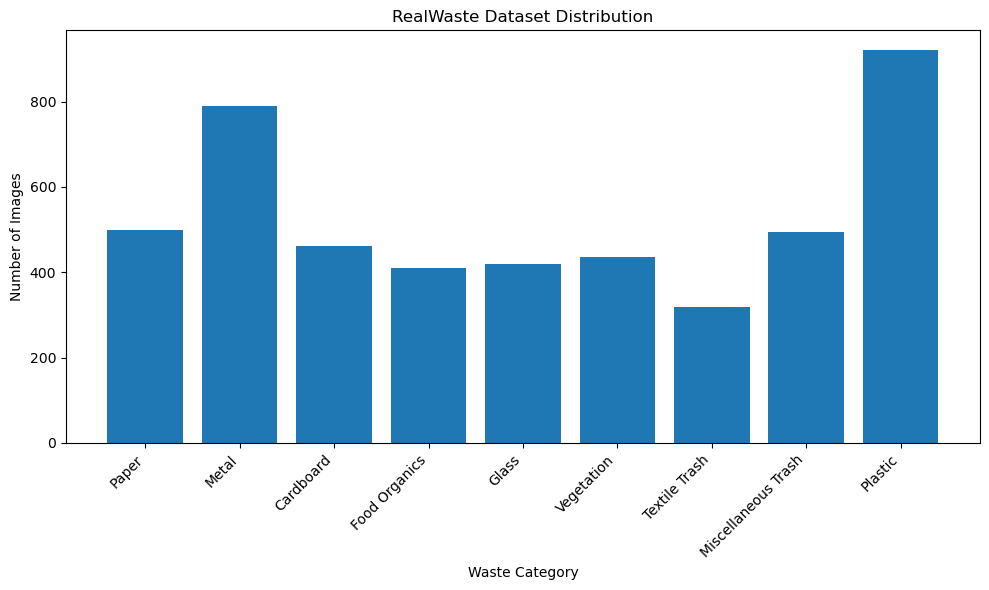

In [98]:
# Distribution chart
plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.keys(),
    category_counts.values()
)

plt.title("RealWaste Dataset Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [145]:
# Create a dataframe containing image characteristics
image_data = []

for category in categories:
    category_path = os.path.join(realwaste_path, category)

    for filename in os.listdir(category_path):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            image_path = os.path.join(category_path, filename)

            try:
                with Image.open(image_path) as img:

                    width, height = img.size

                    image_data.append({
                        "category": category,
                        "filename": filename,
                        "width": width,
                        "height": height,
                        "format": img.format,
                        "mode": img.mode
                    })

            except Exception as e:
                print(f"Could not read {image_path}: {e}")

# Convert the collected information into a DataFrame
image_df = pd.DataFrame(image_data)

print("Total images analyzed:", len(image_df))
print("\nFirst 5 rows:")
display(image_df.head())

print("\nImage formats:")
print(image_df["format"].value_counts())

Total images analyzed: 4752

First 5 rows:


,category,filename,width,height,format,mode
0,Paper,Paper_259.jpg,524,524,JPEG,RGB
1,Paper,Paper_265.jpg,524,524,JPEG,RGB
2,Paper,Paper_271.jpg,524,524,JPEG,RGB
3,Paper,Paper_488.jpg,524,524,JPEG,RGB
4,Paper,Paper_339.jpg,524,524,JPEG,RGB



Image formats:
format
JPEG    4752
Name: count, dtype: int64


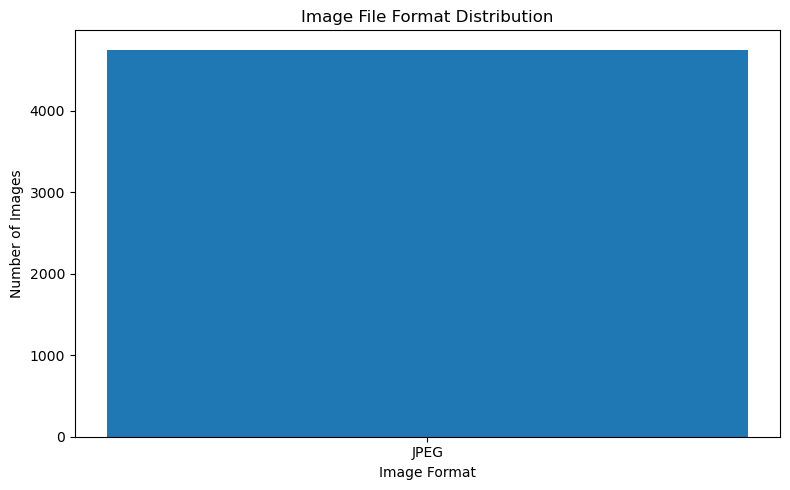

In [143]:
# Visualization 8: Image file formats

format_counts = image_df["format"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    format_counts.index,
    format_counts.values
)

plt.title("Image File Format Distribution")
plt.xlabel("Image Format")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [141]:
# Collect image dimensions

image_dimensions = []
total_images = 0
failed_images = 0

for category in categories:
    category_path = os.path.join(realwaste_path, category)
    
    for filename in os.listdir(category_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            
            image_path = os.path.join(category_path, filename)
            
            try:
                with Image.open(image_path) as img:
                    image_dimensions.append(img.size)
                    total_images += 1
                    
            except Exception as e:
                failed_images += 1

print("Total images:", total_images)
print("Images that could not be opened:", failed_images)

if image_dimensions:
    widths = [size[0] for size in image_dimensions]
    heights = [size[1] for size in image_dimensions]
    
    print("\nImage characteristics:")
    print("Minimum width:", min(widths))
    print("Maximum width:", max(widths))
    print("Average width:", sum(widths) / len(widths))
    print("Minimum height:", min(heights))
    print("Maximum height:", max(heights))
    print("Average height:", sum(heights) / len(heights))

Total images: 4752
Images that could not be opened: 0

Image characteristics:
Minimum width: 524
Maximum width: 524
Average width: 524.0
Minimum height: 524
Maximum height: 524
Average height: 524.0


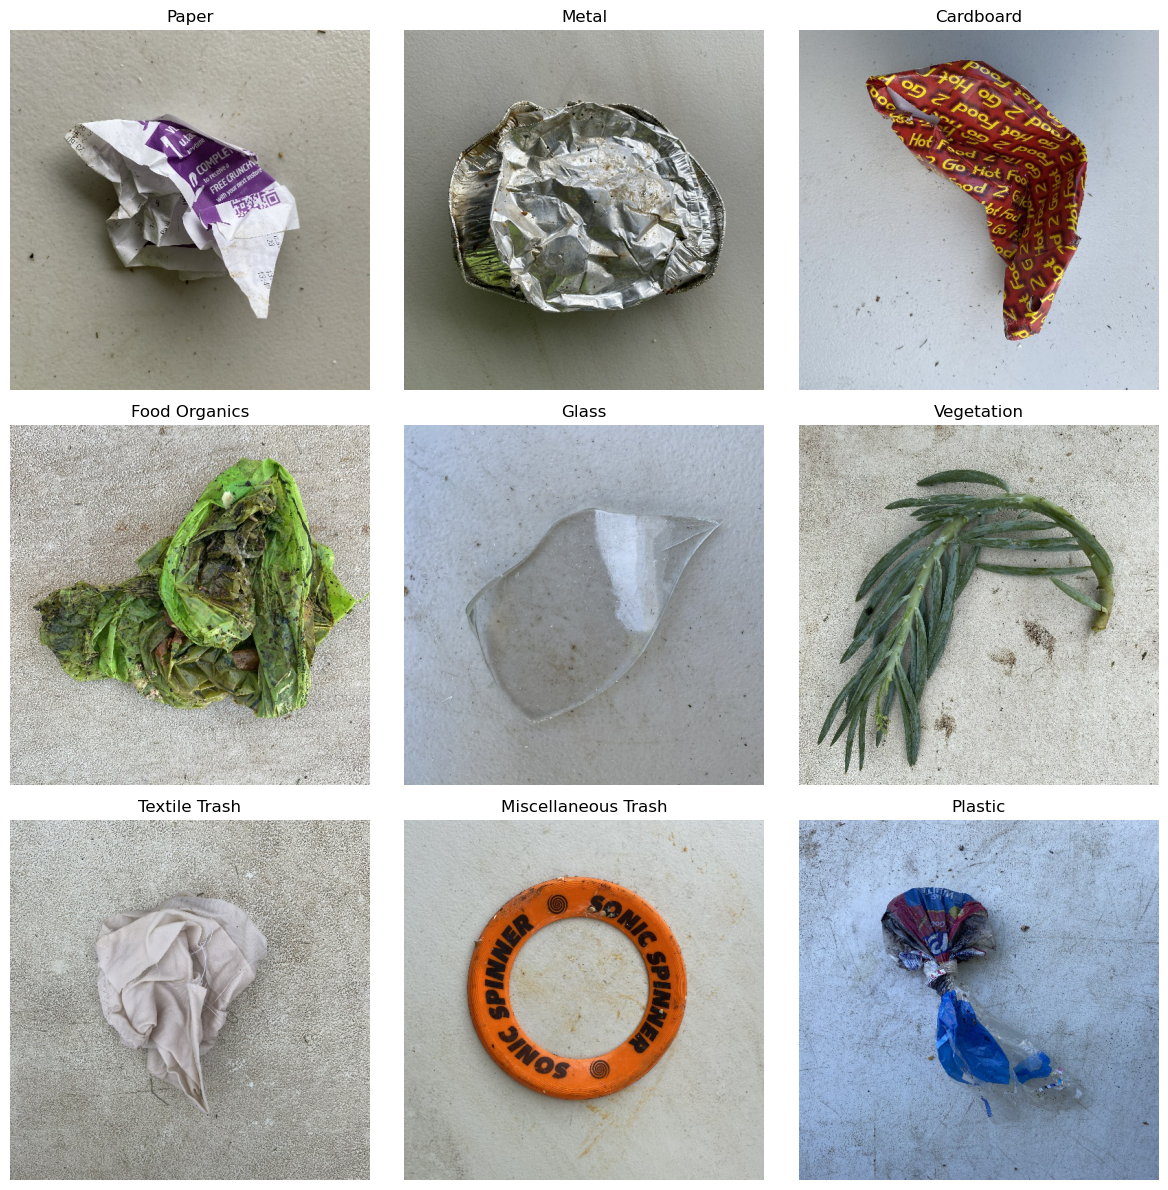

In [139]:
# Display one sample from each waste category


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, category in zip(axes.flat, categories[:9]):
    category_path = os.path.join(realwaste_path, category)
    
    image_files = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    
    if image_files:
        image_path = os.path.join(category_path, image_files[1])
        
        img = Image.open(image_path)
        ax.imshow(img)
        ax.set_title(category)
        ax.axis("off")

plt.tight_layout()
plt.show()

### 1.2 Explore Text Datasets

Text file exists: True
Number of records: 5,000
Vocabulary size: 309
Most common words: [('with', 727), ('sized', 534), ('glass', 424), ('empty', 348), ('bottle', 342), ('food', 316), ('paper', 316), ('box', 313), ('residue', 309), ('plastic', 280), ('metal', 270), ('brand', 247), ('dry', 211), ('new', 196), ('soiled', 189), ('crumpled', 189), ('medium', 187), ('orange', 186), ('stained', 185), ('intact', 184)]

Description length summary:


count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description_word_count, dtype: float64


Category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


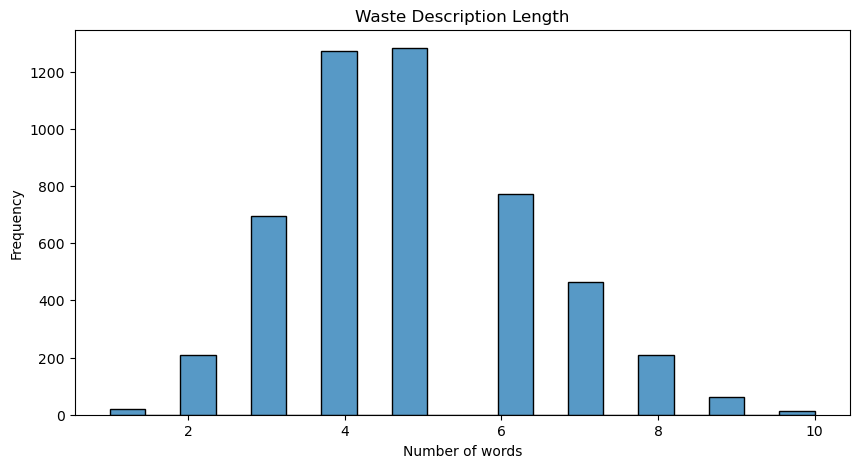

In [137]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# - Load waste_descriptions.csv
project_dir = "/Users/apple/Desktop/MY ANALYSIS/DATA SCIENCE AND MACHINE LEANING/MODULE 5/ASSIGNMENTS/SUMMATIVE LAB 2"
text_file = os.path.join(project_dir, "waste_descriptions.csv")

print("Text file exists:", os.path.exists(text_file))

waste_df = pd.read_csv(text_file)

waste_df["description"] = waste_df["description"].fillna("").astype(str)
waste_df["description_word_count"] = waste_df["description"].str.split().str.len()

all_words = re.findall(r"[A-Za-z]+", " ".join(waste_df["description"]).lower())
vocab = Counter(all_words)

print(f"Number of records: {len(waste_df):,}")
print(f"Vocabulary size: {len(vocab):,}")
print("Most common words:", vocab.most_common(20))

print("\nDescription length summary:")
display(waste_df["description_word_count"].describe())

print("\nCategory distribution:")
print(waste_df["category"].value_counts())

plt.figure(figsize=(10, 5))
sns.histplot(waste_df["description_word_count"], bins=20)
plt.title("Waste Description Length")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()


In [147]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.json
# - Understand document organization and language
# Convert the documents into a DataFrame
policy_file = os.path.join(project_dir, "waste_policy_documents.json")
print("Policy file exists:", os.path.exists(policy_file))

with open(policy_file, "r", encoding="utf-8") as f:
    policy_documents = json.load(f)

policy_df = pd.DataFrame(policy_documents)

print("Number of policy documents:", len(policy_df))
print("\nColumns:")
print(policy_df.columns.tolist())

print("\nFirst 5 documents:")
display(policy_df.head())

print("\nPolicy types:")
print(policy_df["policy_type"].value_counts())

print("\nJurisdictions:")
print(policy_df["jurisdiction"].value_counts())

print("\nWaste categories covered:")
print(policy_df["categories_covered"].explode().value_counts())

print("\nEffective date range:")
print(policy_df["effective_date"].min(), "to", policy_df["effective_date"].max())


Policy file exists: True
Number of policy documents: 14

Columns:
['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']

First 5 documents:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City



Policy types:
policy_type
Textile Trash Recycling Guidelines          1
Glass Recycling Guidelines                  1
Food Organics Recycling Guidelines          1
Plastic Recycling Guidelines                1
Vegetation Recycling Guidelines             1
Cardboard Recycling Guidelines              1
Metal Recycling Guidelines                  1
Paper Recycling Guidelines                  1
Miscellaneous Trash Recycling Guidelines    1
Municipal Waste Guidelines                  1
Residential Recycling Rules                 1
Commercial Recycling Standards              1
Multi-Unit Building Guidelines              1
Community Recycling Program                 1
Name: count, dtype: int64

Jurisdictions:
jurisdiction
Metro City    14
Name: count, dtype: int64

Waste categories covered:
categories_covered
Vegetation             4
Metal                  4
Miscellaneous Trash    4
Textile Trash          3
Glass                  3
Plastic                3
Cardboard              3
Food Organ

In [149]:
# Explore the text of the policy documents

for i, row in policy_df.head(3).iterrows():
    print("=" * 70)
    print("Policy ID:", row["policy_id"])
    print("Policy Type:", row["policy_type"])
    print("Categories:", ", ".join(row["categories_covered"]))
    print("Effective Date:", row["effective_date"])
    print("Jurisdiction:", row["jurisdiction"])
    print("\nDocument Text:")
    print(row["document_text"])
    print()

Policy ID: 1
Policy Type: Textile Trash Recycling Guidelines
Categories: Textile Trash
Effective Date: 2023-11-04
Jurisdiction: Metro City

Document Text:
TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place items in dedicated textile recycling bins or donate to local thrift stores.

Preparation Instructions:
- Ensure all items are clean and dry
- Remove non-textile components when possible
- Bag similar items together

Benefits:
Textile recycling conserves resources and reduces landfill waste.

Policy ID: 2
Policy Type: Glass Recycling Guidelines
Categories: Glass
Effective Date: 2023-01-24
Jurisdiction: Metro City

Document Text:
GLASS RECYCLING 

### 1.3 Create Data Pipelines

In [153]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib

data_dir = pathlib.Path(realwaste_path)

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [155]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

waste_df["clean_description"] = waste_df["description"].map(clean_text)

X_text = waste_df["clean_description"]
y_text = waste_df["category"]

X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X_text, y_text, test_size=0.30, random_state=42, stratify=y_text
)
X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text, test_size=0.50, random_state=42, stratify=y_temp_text
)

print(f"Train: {len(X_train_text)}")
print(f"Validation: {len(X_val_text)}")
print(f"Test: {len(X_test_text)}")
print(f"Number of categories: {y_text.nunique()}")


Train: 3500
Validation: 750
Test: 750
Number of categories: 9


In [157]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here
retrieval_records = []

# Waste description documents
for _, row in waste_df.iterrows():
    category = str(row.get("category", ""))
    description = str(row.get("description", ""))

    parts = [
        f"Category: {category}",
        f"Description: {description}",
        f"Disposal instruction: {row.get('disposal_instruction', '')}",
        f"Common confusion: {row.get('common_confusion', '')}",
        f"Material composition: {row.get('material_composition', '')}"
    ]

    text_parts = []
    for part in parts:
        if part.split(": ", 1)[-1].strip().lower() not in {"nan", "none"}:
            text_parts.append(part)

    retrieval_records.append({
        "source": "waste_descriptions.csv",
        "category": category,
        "text": " ".join(text_parts)
    })

# Policy documents
if not policy_df.empty:
    for _, row in policy_df.iterrows():
        text_parts = []

        for col in policy_df.columns:
            value = row[col]

            if value is None:
                continue

            # Convert list/array-like values to readable text.
            if isinstance(value, (list, tuple, np.ndarray)):
                value = ", ".join(map(str, np.asarray(value).reshape(-1)))

            try:
                missing = bool(pd.isna(value))
            except (ValueError, TypeError):
                missing = False

            if not missing and str(value).strip().lower() not in {"nan", "none"}:
                text_parts.append(f"{col}: {value}")

        # A policy can cover several categories. Create one retrieval
        # record for every category it covers so category-based retrieval works.
        policy_categories = row.get("categories_covered", [])
        if not isinstance(policy_categories, list):
            policy_categories = [str(policy_categories)]

        for covered_category in policy_categories:
            retrieval_records.append({
                "source": "waste_policy_documents.json",
                "category": str(covered_category),
                "text": " ".join(text_parts)
            })

retrieval_df = pd.DataFrame(retrieval_records)

print(f"Retrieval documents: {len(retrieval_df)}")
display(retrieval_df.head(3))

# Create TF-IDF features that will be used as document embeddings.
rag_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

rag_matrix = rag_vectorizer.fit_transform(
    retrieval_df["text"].fillna("").astype(str)
)

print("RAG feature matrix shape:", rag_matrix.shape)


Retrieval documents: 5027


,source,category,text
0,waste_descriptions.csv,Textile Trash,Category: Textile Trash Description: soiled si...
1,waste_descriptions.csv,Glass,Category: Glass Description: folded glass bott...
2,waste_descriptions.csv,Food Organics,Category: Food Organics Description: large Sup...


RAG feature matrix shape: (5027, 7601)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [159]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))
print("Batch size:", BATCH_SIZE)
print("Using MobileNetV2 ImageNet preprocessing.")


Image size: (224, 224)
Batch size: 32
Using MobileNetV2 ImageNet preprocessing.


### 2.2 Implement CNN Model with Transfer Learning

In [161]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here
if not TF_AVAILABLE:
    raise ImportError("TensorFlow is required for the CNN section.")

try:
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )
    weights_used = "ImageNet"
except Exception as e:
    print("ImageNet weights could not be loaded:", e)
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights=None
    )
    weights_used = "None"

base_model.trainable = False

# MobileNetV2 expects inputs scaled to [-1, 1].
transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Rescaling(1.0 / 127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation="softmax"),
], name="EcoSort_MobileNetV2")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model = transfer_model

print("Weights:", weights_used)
cnn_model.summary()


Weights: ImageNet


Model: "EcoSort_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.3 Train and Evaluate the Model

In [163]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

if not TF_AVAILABLE:
    raise ImportError("TensorFlow is required for CNN training.")

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ],
    verbose=1
)

print("Initial transfer-learning training completed.")


Epoch 1/10


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 667ms/step - accuracy: 0.2112 - loss: 2.1917 - val_accuracy: 0.3170 - val_loss: 1.8341
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 686ms/step - accuracy: 0.4332 - loss: 1.6244 - val_accuracy: 0.5000 - val_loss: 1.4463
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 79s 665ms/step - accuracy: 0.5576 - loss: 1.3222 - val_accuracy: 0.5745 - val_loss: 1.2276
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 79s 665ms/step - accuracy: 0.6236 - loss: 1.1424 - val_accuracy: 0.6404 - val_loss: 1.0939
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 671ms/step - accuracy: 0.6639 - loss: 1.0245 - val_accuracy: 0.6787 - val_loss: 1.0044
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 81s 684ms/step - accuracy: 0.6928 - loss: 0.9402 - val_accuracy: 0.7000 - val_loss: 0.9399
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 676ms/step - accuracy: 0.7159 - loss: 0.8759 - val_accuracy: 0.7128 - val_loss: 0.8911
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 677ms/step - accuracy: 0.7299 - loss: 0.8245 - val

Test loss: 0.7910
Test accuracy: 0.7229


2026-09-30 23:17:08.503878: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Classification report:
                     precision    recall  f1-score   support

          Cardboard       0.49      0.68      0.57        37
      Food Organics       0.75      0.83      0.79        36
              Glass       0.76      0.70      0.73        37
              Metal       0.83      0.78      0.81        93
Miscellaneous Trash       0.53      0.38      0.44        52
              Paper       0.75      0.71      0.73        66
            Plastic       0.70      0.78      0.74        81
      Textile Trash       0.76      0.74      0.75        43
         Vegetation       0.91      0.89      0.90        35

           accuracy                           0.72       480
          macro avg       0.72      0.72      0.72       480
       weighted avg       0.73      0.72      0.72       480



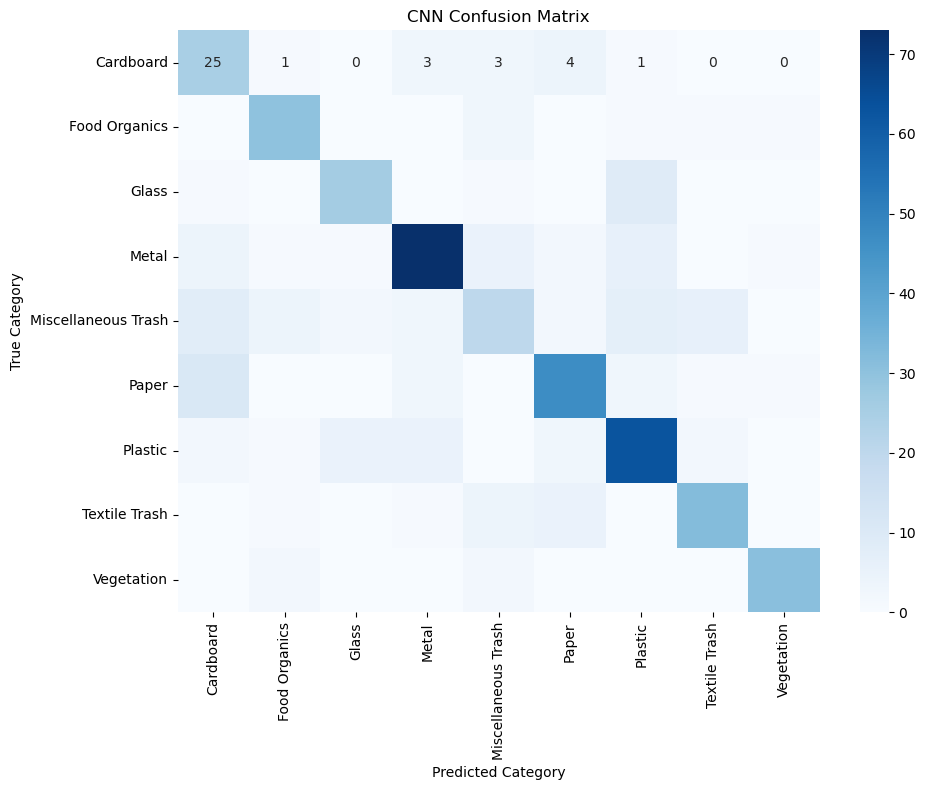

In [165]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

if not TF_AVAILABLE:
    raise ImportError("TensorFlow is required for CNN evaluation.")

test_loss, test_accuracy = cnn_model.evaluate(test_dataset, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Collect true and predicted labels.
y_true_cnn = []
y_pred_cnn = []

for images, labels in test_dataset:
    probabilities = cnn_model.predict(images, verbose=0)
    y_true_cnn.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(probabilities, axis=1))

print("\nClassification report:")
print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0
    )
)

cm_cnn = confusion_matrix(
    y_true_cnn,
    y_pred_cnn,
    labels=list(range(num_classes))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()


### 2.4 Fine-tune the Model

In [167]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

if not TF_AVAILABLE:
    raise ImportError("TensorFlow is required for fine-tuning.")

base_model.trainable = True

fine_tune_at = max(0, len(base_model.layers) - 30)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen, as recommended for stable
# transfer learning in the recap.
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=5,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ],
    verbose=1
)

fine_test_loss, fine_test_accuracy = cnn_model.evaluate(
    test_dataset, verbose=0
)

print(f"Fine-tuned test loss: {fine_test_loss:.4f}")
print(f"Fine-tuned test accuracy: {fine_test_accuracy:.4f}")


Epoch 1/5


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 689ms/step - accuracy: 0.7733 - loss: 0.6421 - val_accuracy: 0.7723 - val_loss: 0.6543
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 691ms/step - accuracy: 0.8330 - loss: 0.4951 - val_accuracy: 0.7872 - val_loss: 0.5987
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 719ms/step - accuracy: 0.8680 - loss: 0.4051 - val_accuracy: 0.8191 - val_loss: 0.5653
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 85s 717ms/step - accuracy: 0.8964 - loss: 0.3355 - val_accuracy: 0.8340 - val_loss: 0.5414
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 85s 715ms/step - accuracy: 0.9166 - loss: 0.2795 - val_accuracy: 0.8383 - val_loss: 0.5240
Fine-tuned test loss: 0.5105
Fine-tuned test accuracy: 0.8333


## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [169]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

waste_df["clean_description"] = waste_df["description"].map(clean_text)

X_text = waste_df["clean_description"].values
y_text = waste_df["category"].astype(str).values

X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X_text, y_text, test_size=0.30, random_state=42, stratify=y_text
)

X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text, test_size=0.50, random_state=42, stratify=y_temp_text
)

print(f"Train: {len(X_train_text)}")
print(f"Validation: {len(X_val_text)}")
print(f"Test: {len(X_test_text)}")
print(f"Number of categories: {len(np.unique(y_text))}")

# Integer labels for the neural-network output.
text_label_encoder = LabelEncoder()
y_train_text_encoded = text_label_encoder.fit_transform(y_train_text)
y_val_text_encoded = text_label_encoder.transform(y_val_text)
y_test_text_encoded = text_label_encoder.transform(y_test_text)

text_class_names = list(text_label_encoder.classes_)
text_num_classes = len(text_class_names)

# Match the recap's sequence-classification setup.
vocab_size = 10000
max_len = 200

text_vectorizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=max_len,
    standardize=None
)

text_vectorizer.adapt(X_train_text)

X_train_seq = text_vectorizer(np.array(X_train_text)).numpy().astype("int32")
X_val_seq = text_vectorizer(np.array(X_val_text)).numpy().astype("int32")
X_test_seq = text_vectorizer(np.array(X_test_text)).numpy().astype("int32")

print("Sequence shapes:")
print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)


Train: 3500
Validation: 750
Test: 750
Number of categories: 9
Sequence shapes:
(3500, 200) (750, 200) (750, 200)


### 3.2 Implement Text Classification Model

In [171]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

text_model = keras.Sequential([
    layers.Input(shape=(max_len,), dtype="int32"),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    ),

    layers.Bidirectional(
        layers.LSTM(64)
    ),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(text_num_classes, activation="softmax"),
], name="EcoSort_Bidirectional_LSTM")

text_model.compile(
    optimizer=keras.optimizers.Adam(clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

text_model.summary()


Model: "EcoSort_Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,889 (2.73 MB)

 Trainable params: 714,889 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Train and Evaluate the Model

In [173]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here
text_history = text_model.fit(
    X_train_seq,
    y_train_text_encoded,
    validation_data=(X_val_seq, y_val_text_encoded),
    epochs=5,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )
    ],
    verbose=1
)

train_text_loss, train_text_accuracy = text_model.evaluate(
    X_train_seq, y_train_text_encoded, verbose=0
)
val_text_loss, val_text_accuracy = text_model.evaluate(
    X_val_seq, y_val_text_encoded, verbose=0
)

print(f"Training accuracy:   {train_text_accuracy:.4f}")
print(f"Validation accuracy: {val_text_accuracy:.4f}")


Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.3549 - loss: 2.1008 - val_accuracy: 0.6093 - val_loss: 1.6848
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7909 - loss: 0.8405 - val_accuracy: 0.9827 - val_loss: 0.1730
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9703 - loss: 0.1588 - val_accuracy: 0.9933 - val_loss: 0.0320
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9911 - loss: 0.0578 - val_accuracy: 0.9933 - val_loss: 0.0219
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9949 - loss: 0.0384 - val_accuracy: 0.9987 - val_loss: 0.0121
Training accuracy:   0.9997
Validation accuracy: 0.9987


Text test accuracy: 1.0000

Classification report:
                     precision    recall  f1-score   support

          Cardboard       1.00      1.00      1.00        88
      Food Organics       1.00      1.00      1.00        77
              Glass       1.00      1.00      1.00        83
              Metal       1.00      1.00      1.00        76
Miscellaneous Trash       1.00      1.00      1.00        87
              Paper       1.00      1.00      1.00        76
            Plastic       1.00      1.00      1.00        85
      Textile Trash       1.00      1.00      1.00        88
         Vegetation       1.00      1.00      1.00        90

           accuracy                           1.00       750
          macro avg       1.00      1.00      1.00       750
       weighted avg       1.00      1.00      1.00       750



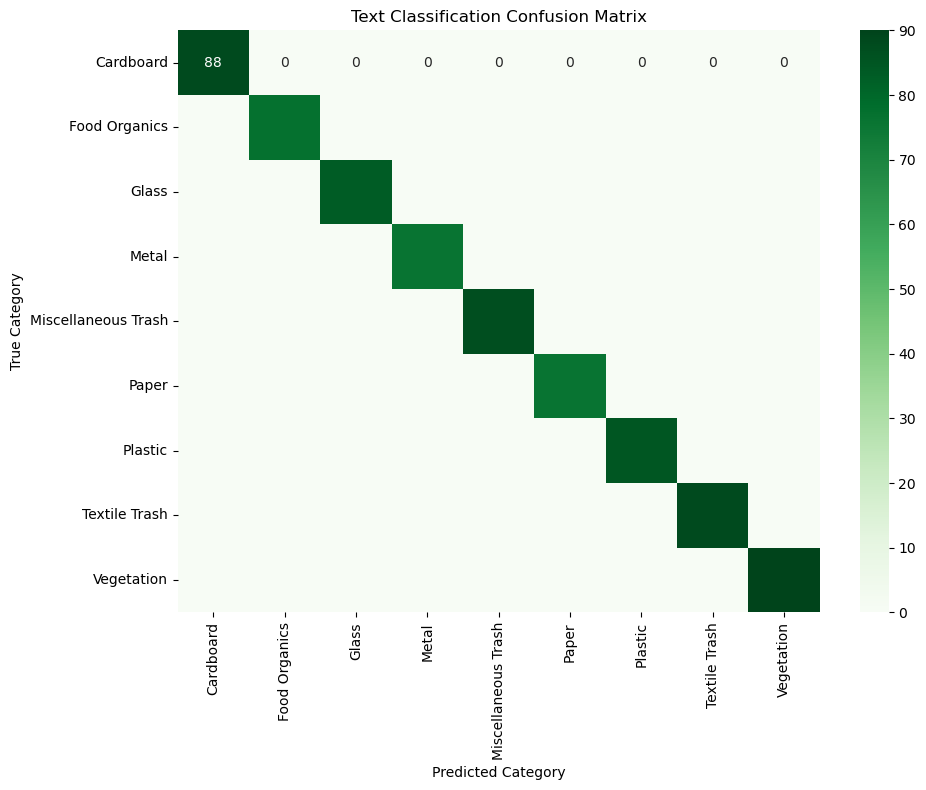

In [129]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

text_test_loss, text_test_accuracy = text_model.evaluate(
    X_test_seq,
    y_test_text_encoded,
    verbose=0
)

print(f"Text test loss: {text_test_loss:.4f}")
print(f"Text test accuracy: {text_test_accuracy:.4f}")

text_probabilities = text_model.predict(X_test_seq, verbose=0)
text_predictions_encoded = np.argmax(text_probabilities, axis=1)

print("\nClassification report:")
print(
    classification_report(
        y_test_text_encoded,
        text_predictions_encoded,
        labels=list(range(text_num_classes)),
        target_names=text_class_names,
        zero_division=0
    )
)

cm_text = confusion_matrix(
    y_test_text_encoded,
    text_predictions_encoded,
    labels=list(range(text_num_classes))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_text,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=text_class_names,
    yticklabels=text_class_names
)
plt.title("Bidirectional LSTM Text Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()


### 3.4 Create Classification Function

In [174]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classify a waste description using the trained Bidirectional LSTM.
    """
    if not isinstance(description, str) or not description.strip():
        raise ValueError("Please provide a non-empty text description.")

    cleaned = clean_text(description)
    sequence = text_vectorizer(np.array([cleaned])).numpy().astype("int32")

    probabilities = text_model.predict(sequence, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))

    return str(text_class_names[predicted_index])

example_description = "A clear plastic bottle used for drinking water."
print("Example prediction:", classify_waste_description(example_description))


Example prediction: Plastic


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [177]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here
if "retrieval_df" not in globals() or retrieval_df.empty:
    retrieval_records = []

    for _, row in waste_df.iterrows():
        category = str(row.get("category", ""))
        parts = [
            f"Category: {category}",
            f"Description: {row.get('description', '')}",
            f"Disposal instruction: {row.get('disposal_instruction', '')}",
            f"Common confusion: {row.get('common_confusion', '')}",
            f"Material composition: {row.get('material_composition', '')}"
        ]

        retrieval_records.append({
            "source": "waste_descriptions.csv",
            "category": category,
            "text": " ".join(parts)
        })

    for _, row in policy_df.iterrows():
        text_parts = []
        for col in policy_df.columns:
            value = row[col]

            if isinstance(value, (list, tuple, np.ndarray)):
                value = ", ".join(map(str, np.asarray(value).reshape(-1)))

            try:
                if bool(pd.isna(value)):
                    continue
            except (ValueError, TypeError):
                pass

            text_parts.append(f"{col}: {value}")

        retrieval_records.append({
            "source": "waste_policy_documents.json",
            "category": str(row.get("category", "")),
            "text": " ".join(text_parts)
        })

    retrieval_df = pd.DataFrame(retrieval_records)

rag_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

rag_matrix = rag_vectorizer.fit_transform(
    retrieval_df["text"].fillna("").astype(str)
)

print(f"Documents indexed: {len(retrieval_df)}")
print(f"Embedding matrix: {rag_matrix.shape}")


Documents indexed: 5027
Embedding matrix: (5027, 7601)


### 4.2 Implement RAG-based System

In [181]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here
def retrieve_documents(query, top_k=3):
    """Return the top-k documents most similar to a waste-related query."""
    if not isinstance(query, str) or not query.strip():
        return pd.DataFrame(columns=retrieval_df.columns)

    query_vector = rag_vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(query_vector, rag_matrix).ravel()

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = retrieval_df.iloc[top_indices].copy()
    results["similarity"] = scores[top_indices]

    return results.reset_index(drop=True)

# Optional local text-generation model.
# local_files_only=True prevents the notebook from unexpectedly downloading
# a large model. The system has an extractive/template fallback if the model
# is not already installed and cached.
# ============================================================
# Transformers setup for the RAG section
# ============================================================

TRANSFORMERS_AVAILABLE = False
pipeline = None

try:
    from transformers import pipeline
    TRANSFORMERS_AVAILABLE = True
    print("Transformers is available.")
except ImportError:
    print("Transformers is not installed.")
    print("The RAG system will use the extractive/template fallback.")

rag_generator = None

if TRANSFORMERS_AVAILABLE:
    try:
        rag_generator = pipeline(
            "text2text-generation",
            model="google/flan-t5-small",
            local_files_only=True
        )
        print("Local FLAN-T5 generator loaded.")
    except Exception:
        print(
            "No local generative Transformer was available. "
            "Using the policy-grounded fallback generator."
        )

print("RAG retrieval mechanism is ready.")


Transformers is available.
No local generative Transformer was available. Using the policy-grounded fallback generator.
RAG retrieval mechanism is ready.


### 4.3 Adjust and Evaluate the System

In [183]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

RAG_TOP_K = 3
RAG_MIN_SIMILARITY = 0.05

def build_rag_context(waste_category, top_k=RAG_TOP_K):
    """Retrieve policy and description context for a waste category."""
    results = retrieve_documents(waste_category, top_k=top_k)

    if results.empty:
        return "", results

    relevant = results[results["similarity"] >= RAG_MIN_SIMILARITY].copy()

    if relevant.empty:
        relevant = results.head(1).copy()

    context = "\n\n".join(
        f"Source: {row['source']}\n{row['text']}"
        for _, row in relevant.iterrows()
    )

    return context, relevant

print(f"RAG_TOP_K = {RAG_TOP_K}")
print(f"RAG_MIN_SIMILARITY = {RAG_MIN_SIMILARITY}")


RAG_TOP_K = 3
RAG_MIN_SIMILARITY = 0.05


In [185]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here
evaluation_categories = sorted(
    [str(x) for x in waste_df["category"].dropna().unique()]
)

rag_evaluation = []

for category in evaluation_categories:
    results = retrieve_documents(category, top_k=RAG_TOP_K)

    if results.empty:
        rag_evaluation.append({
            "category": category,
            "top_similarity": 0.0,
            "documents_retrieved": 0
        })
        continue

    rag_evaluation.append({
        "category": category,
        "top_similarity": float(results["similarity"].max()),
        "documents_retrieved": len(results)
    })

rag_evaluation_df = pd.DataFrame(rag_evaluation)

print("RAG retrieval evaluation:")
display(rag_evaluation_df)

print(
    f"Average top-document similarity: "
    f"{rag_evaluation_df['top_similarity'].mean():.4f}"
)


RAG retrieval evaluation:


,category,top_similarity,documents_retrieved
0,Cardboard,0.348947,3
1,Food Organics,0.281148,3
2,Glass,0.507735,3
3,Metal,0.479936,3
4,Miscellaneous Trash,0.217903,3
5,Paper,0.445660,3
6,Plastic,0.382157,3
7,Textile Trash,0.284361,3
8,Vegetation,0.159911,3


Average top-document similarity: 0.3453


### 4.4 Create Instruction Generation Function

In [187]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates recycling/disposal instructions for a waste category using
    retrieved waste descriptions and policy documents.

    Args:
        waste_category (str): Waste category.

    Returns:
        tuple: (instruction_text, relevant_policy_documents)
    """
    if not isinstance(waste_category, str) or not waste_category.strip():
        raise ValueError("Please provide a non-empty waste category.")

    category = waste_category.strip()

    context, relevant_docs = build_rag_context(
        category,
        top_k=RAG_TOP_K
    )

    if relevant_docs.empty:
        return (
            f"No policy information was retrieved for '{category}'. "
            "Please consult the local waste authority before disposal.",
            []
        )

    # Use a local generative model if it is already available.
    if rag_generator is not None:
        prompt = (
            "Using ONLY the information in the context below, provide concise "
            "waste disposal instructions. Do not invent rules.\n\n"
            f"Context:\n{context}\n\n"
            f"Waste category: {category}\n"
            "Instructions:"
        )

        try:
            generated = rag_generator(
                prompt,
                max_new_tokens=120,
                do_sample=False
            )[0]["generated_text"]

            instruction_text = generated.strip()

        except Exception:
            instruction_text = ""

    else:
        instruction_text = ""

    # Policy-grounded fallback when no local generator is available.
    if not instruction_text:
        policy_rows = relevant_docs[
            relevant_docs["source"].str.contains("policy", case=False, na=False)
        ]

        source_rows = policy_rows if not policy_rows.empty else relevant_docs

        instruction_lines = [
            f"Recycling guidance for {category}:"
        ]

        for _, row in source_rows.head(3).iterrows():
            instruction_lines.append(
                f"- {row['text']}"
            )

        instruction_text = "\n".join(instruction_lines)

    source_documents = relevant_docs[
        ["source", "category", "similarity"]
    ].to_dict("records")

    return instruction_text, source_documents


# Example
example_instruction, example_sources = generate_recycling_instructions(
    evaluation_categories[0] if evaluation_categories else "Plastic"
)

print(example_instruction)
print("\nRetrieved sources:")
display(pd.DataFrame(example_sources))


Recycling guidance for Cardboard:
- policy_id: 6 policy_type: Cardboard Recycling Guidelines categories_covered: Cardboard effective_date: 2023-11-24 document_text: CARDBOARD RECYCLING GUIDELINES

Acceptable Items:
- Corrugated cardboard boxes
- Paperboard (cereal boxes, etc.)
- Cardboard packaging
- Cardboard tubes
- Clean pizza boxes

Non-Acceptable Items:
- Waxed cardboard
- Cardboard with food residue
- Cardboard with plastic linings
- Foam inserts
- Packing peanuts

Collection Method:
Flatten and place in recycling bins or take to cardboard recycling centers.

Preparation Instructions:
- Remove all non-cardboard packaging
- Flatten boxes to save space
- Keep dry and clean

Benefits:
Recycling cardboard saves trees and reduces landfill volume significantly. jurisdiction: Metro City

Retrieved sources:


,source,category,similarity
0,waste_policy_documents.json,Cardboard,0.348947
1,waste_descriptions.csv,Cardboard,0.319059
2,waste_descriptions.csv,Cardboard,0.317775


## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [189]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

# Integration architecture
#
#                 ┌─────────────────────┐
#                 │   User Input        │
#                 │ image OR text       │
#                 └──────────┬──────────┘
#                            │
#                  ┌─────────▼─────────┐
#                  │ Input Processing  │
#                  └─────────┬─────────┘
#                            │
#              ┌─────────────┴─────────────┐
#              │                           │
#        Image input                 Text input
#              │                           │
#              ▼                           ▼
#       CNN classifier              Text classifier
#              │                           │
#              └─────────────┬─────────────┘
#                            │
#                            ▼
#                    Predicted category
#                            │
#                            ▼
#                     RAG retrieval
#                            │
#                            ▼
#                  Recycling instructions
#                            │
#                            ▼
#                    Assistant response
#
# The two classifiers provide the waste category. The RAG component then
# grounds the final disposal guidance in the supplied descriptions and
# policy documents.

print("Architecture: Image/Text input -> classifier -> category -> RAG retrieval -> instructions.")


Architecture: Image/Text input -> classifier -> category -> RAG retrieval -> instructions.


### 5.2 Implement Integrated Assistant

In [191]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Processes an image or text description and returns the predicted waste
    category, confidence, recycling instructions, and retrieval sources.

    Args:
        input_data: Image path/PIL image/numpy array or text description.
        input_type (str): "image" or "text".

    Returns:
        dict: Classification and recycling information.
    """
    input_type = str(input_type).lower().strip()

    if input_type == "text":
        if not isinstance(input_data, str) or not input_data.strip():
            raise ValueError("Text input must be a non-empty string.")

        cleaned = clean_text(input_data)
        sequence = text_vectorizer(np.array([cleaned])).numpy().astype("int32")

        probabilities = text_model.predict(sequence, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        category = str(text_class_names[predicted_index])
        confidence = float(probabilities[predicted_index])

        instruction_text, sources = generate_recycling_instructions(category)

        return {
            "input_type": "text",
            "category": category,
            "confidence": confidence,
            "recycling_instructions": instruction_text,
            "sources": sources
        }

    elif input_type == "image":
        if not TF_AVAILABLE:
            raise ImportError("TensorFlow is required for image classification.")

        # Accept a file path, PIL image, or NumPy array.
        if isinstance(input_data, (str, os.PathLike)):
            if not os.path.exists(input_data):
                raise FileNotFoundError(f"Image not found: {input_data}")
            image = Image.open(input_data).convert("RGB")
        elif isinstance(input_data, Image.Image):
            image = input_data.convert("RGB")
        else:
            image = Image.fromarray(np.asarray(input_data).astype("uint8")).convert("RGB")

        image = image.resize((IMG_WIDTH, IMG_HEIGHT))
        image_array = np.asarray(image, dtype=np.float32)

        probabilities = cnn_model.predict(
            np.expand_dims(image_array, axis=0),
            verbose=0
        )[0]

        predicted_index = int(np.argmax(probabilities))
        category = class_names[predicted_index]
        confidence = float(probabilities[predicted_index])

        instruction_text, sources = generate_recycling_instructions(category)

        return {
            "input_type": "image",
            "category": category,
            "confidence": confidence,
            "recycling_instructions": instruction_text,
            "sources": sources
        }

    else:
        raise ValueError("input_type must be either 'image' or 'text'.")


# Example using text input
assistant_example = waste_management_assistant(
    "An empty plastic bottle used for drinking water.",
    input_type="text"
)

print("Category:", assistant_example["category"])
print("Confidence:", f"{assistant_example['confidence']:.3f}")
print("\nInstructions:")
print(assistant_example["recycling_instructions"])


Category: Plastic
Confidence: 1.000

Instructions:
Recycling guidance for Plastic:
- Category: Plastic Description: plastic lid Disposal instruction: If unmarked or non-recyclable plastic, place in general waste. Common confusion: Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on containers. Material composition: Polymer materials derived from petrochemicals or plant-based sources.
- Category: Plastic Description: dry plastic bag Disposal instruction: If unmarked or non-recyclable plastic, place in general waste. Common confusion: Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on containers. Material composition: Polymer materials derived from petrochemicals or plant-based sources.
- Category: Plastic Description: green plastic lid Disposal instruction: If unmarked or non-recyclable plastic, place in general waste. Common confusion: Plastic bags often can not go in general recycling. Check for recycling numbe

### 5.3 Evaluate the Integrated System

In [195]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

# -------------------------
# Text test cases
# -------------------------
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset

# -------------------------
# Text test cases
# -------------------------
text_results = []

for description, true_category in zip(
    X_test_text[:10],
    y_test_text[:10]
):
    result = waste_management_assistant(
        description,
        input_type="text"
    )

    text_results.append({
        "true_category": true_category,
        "predicted_category": result["category"],
        "confidence": result["confidence"],
        "correct": true_category == result["category"]
    })

text_results_df = pd.DataFrame(text_results)

print("Text test results:")
display(text_results_df)

print(
    f"\nText assistant accuracy: "
    f"{text_results_df['correct'].mean():.2%}"
)

# -------------------------
# Image test cases
# -------------------------
if TF_AVAILABLE:
    image_results = []
    max_image_cases = 10

    for images, labels in test_dataset.take(10):
        probabilities = cnn_model.predict(images, verbose=0)
        predicted_indices = np.argmax(probabilities, axis=1)
        true_indices = np.argmax(labels.numpy(), axis=1)

        for true_idx, pred_idx, probs in zip(
            true_indices,
            predicted_indices,
            probabilities
        ):
            image_results.append({
                "true_category": class_names[int(true_idx)],
                "predicted_category": class_names[int(pred_idx)],
                "confidence": float(np.max(probs)),
                "correct": int(true_idx) == int(pred_idx)
            })

            if len(image_results) >= max_image_cases:
                break

        if len(image_results) >= max_image_cases:
            break

    image_results_df = pd.DataFrame(image_results)

    print("\nIntegrated image evaluation:")
    display(image_results_df)

    if not image_results_df.empty:
        print(
            "Image accuracy on sampled integrated tests:",
            f"{image_results_df['correct'].mean():.4f}"
        )
else:
    print("\nImage evaluation skipped because TensorFlow is unavailable.")


Text test results:


,true_category,predicted_category,confidence,correct
0,Food Organics,Food Organics,0.999378,True
1,Metal,Metal,0.998320,True
2,Paper,Paper,0.999519,True
3,Textile Trash,Textile Trash,0.999973,True
4,Textile Trash,Textile Trash,0.999998,True
5,Textile Trash,Textile Trash,0.999985,True
6,Plastic,Plastic,0.997471,True
7,Textile Trash,Textile Trash,1.000000,True
8,Glass,Glass,0.994500,True
9,Miscellaneous Trash,Miscellaneous Trash,1.000000,True



Text assistant accuracy: 100.00%

Integrated image evaluation:


,true_category,predicted_category,confidence,correct
0,Paper,Glass,0.439993,False
1,Metal,Metal,0.986700,True
2,Metal,Metal,0.988902,True
3,Plastic,Plastic,0.687884,True
4,Miscellaneous Trash,Miscellaneous Trash,0.980031,True
5,Vegetation,Vegetation,0.576644,True
6,Food Organics,Food Organics,0.999952,True
7,Plastic,Plastic,0.950737,True
8,Miscellaneous Trash,Food Organics,0.500900,False
9,Metal,Metal,0.573409,True


Image accuracy on sampled integrated tests: 0.8000


## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.